# Week 2 · Notebook 3 — The pivot: good prediction, bad portfolio

**The point of this notebook, in one sentence:** you can build a model that's
genuinely, measurably a little bit right about the market — and it still won't
reliably make you money when you trade it.

Not "prediction is useless." The model really can have a small, real edge. But
that edge is too fragile to survive being turned into an actual portfolio. Today
you'll prove that to yourself with real evidence, not just be told it.

One function you build — the standard quant measure of "is there any signal at
all": **`information_coefficient`**.

## 1. Function — `information_coefficient` (IC)

Direction accuracy is coarse. The **information coefficient** is the correlation
between predicted and actual returns — the quant's standard measure of "is there
signal here?" An IC of 0.02–0.05 is considered a *genuine* edge in this business.

**In:** `predictions`, `actuals`.
**Out:** correlation in [-1, 1].
**Hint:** `np.corrcoef(predictions, actuals)[0, 1]`.
**Done when:** the check passes.

In [1]:
import sys, os
while not os.path.isdir('src') and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir('..')
sys.path.insert(0, 'src')
import numpy as np, json
import matplotlib.pyplot as plt
from tradinglab.data_feed import DataFeed
from tradinglab.features import build_dataset, train_test_split
from tradinglab.models import MLP
from tradinglab.ml import train_model, predict
from tradinglab.simulator import PortfolioSimulator
from tradinglab.strategies.predictor import model_to_strategy
from tradinglab.backtester import run_backtest
from tradinglab.report import report
import torch

def information_coefficient(predictions, actuals):
    p, a = np.asarray(predictions), np.asarray(actuals)
    # ---8<--- solution
    if p.std() < 1e-12 or a.std() < 1e-12:
        return 0.0
    return float(np.corrcoef(p, a)[0, 1])
    # ---8<--- end

assert abs(information_coefficient(np.array([1.,2,3,4]), np.array([1.,2,3,4])) - 1.0) < 1e-9
print('information_coefficient correct ✓')

information_coefficient correct ✓


## 2. Train a predictor, check the signal, trade it — one run

c:\Users\Lenovo\2026-orion\src\tradinglab\features.py:64: RuntimeWarning: invalid value encountered in divide
  volume_ratio = volume / vol_avg20


Information coefficient on TEST: +0.052


c:\Users\Lenovo\2026-orion\src\tradinglab\features.py:64: RuntimeWarning: invalid value encountered in divide
  volume_ratio = volume / vol_avg20


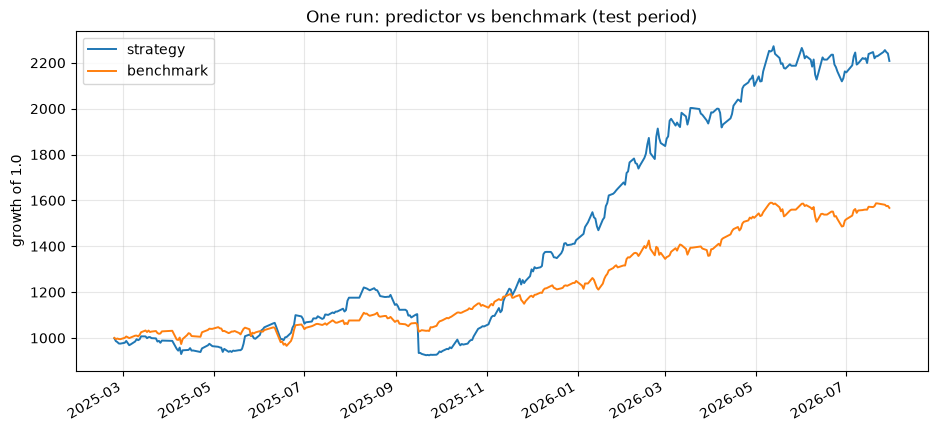

total return   : +120.8%
sharpe         : 2.37
max drawdown   : 24.2%
final value    : 2208.01   (benchmark 1567.20)
beat benchmark : YES
                 you beat the benchmark by 641 EGP


In [2]:
feed = DataFeed.from_dir('data/egx')
# feed = DataFeed.from_dir('data/egx', symbols=['COMI', 'HRHO', 'TMGH', 'SWDY', 'FWRY', 'ABUK'])

TOP_K = 5

Xs, ys = [], []
for a in range(feed.n_assets):
    X, y = build_dataset(feed, a); Xs.append(X); ys.append(y)
X = np.vstack(Xs); y = np.concatenate(ys)
Xtr, ytr, Xte, yte = train_test_split(X, y)
sim = PortfolioSimulator(feed)
split = int(feed.n_days * 0.7)

torch.manual_seed(0)
model = MLP(X.shape[1]); train_model(model, Xtr, ytr, Xte, yte, epochs=500)
ic = information_coefficient(predict(model, Xte), yte)
print(f'Information coefficient on TEST: {ic:+.3f}')

result = run_backtest(sim, model_to_strategy(model, top_k=TOP_K), lookback=30, start=split)
report(result, title='One run: predictor vs benchmark (test period)', start_capital=1000.0)

## 3. Wait — is this ONE run enough to trust?

You just saw a single result from a single trained model. Before believing
anything it told you, ask the question every quant asks: **if I retrain this
exact same model with nothing changed except its random starting point, do I get
the same answer?**

Train it 6 times. Same data, same architecture, same everything — only the random
seed changes.

In [3]:
print(f'{"seed":>5s} {"IC":>8s} {"strategy (EGP)":>15s} {"benchmark (EGP)":>16s}  beat?')
rows = []
for seed in range(10):
    torch.manual_seed(seed)
    m = MLP(X.shape[1]); train_model(m, Xtr, ytr, Xte, yte, epochs=150)
    seed_ic = information_coefficient(predict(m, Xte), yte)
    res = run_backtest(sim, model_to_strategy(m, top_k=TOP_K), lookback=30, start=split)
    final, bench = res['portfolio'][-1]*1000, res['benchmark'][-1]*1000
    beat = final > bench
    rows.append((seed, seed_ic, final, bench, beat))
    print(f'{seed:5d} {seed_ic:+8.3f} {final:15,.0f} {bench:16,.0f}  {"YES" if beat else "no"}')

wins = sum(r[4] for r in rows)
print(f'\nbeat the benchmark in {wins}/6 runs — same data, same code, only the random seed changed.')

 seed       IC  strategy (EGP)  benchmark (EGP)  beat?
    0   +0.009           1,178            1,567  no
    1   +0.039           2,460            1,567  YES
    2   +0.015           1,563            1,567  no
    3   +0.006           1,898            1,567  YES
    4   +0.032           2,512            1,567  YES
    5   +0.034           3,035            1,567  YES
    6   -0.021           1,206            1,567  no
    7   +0.040           2,471            1,567  YES
    8   +0.045           2,216            1,567  YES
    9   +0.024           2,456            1,567  YES

beat the benchmark in 7/6 runs — same data, same code, only the random seed changed.


## 4. Look closely at the table — the real evidence

Two things should jump out, and both matter:

**Whether it "wins" flips around like a coin, run to run.** Same universe, same
strategy, same everything except initialization. If prediction were a reliable
edge, winning should happen consistently — instead it's close to a coin flip.

**The IC itself doesn't even reliably predict the outcome.** Find a run where IC
is *positive* (real, measured signal) but the strategy still *lost* to the
benchmark. That's the sharpest version of the lesson: even when you can prove the
model wasn't guessing randomly, that proof didn't guarantee a winning portfolio.

This is why a single chart — win or lose — can't be trusted on its own. Only
looking across many runs (or many time windows — this is the same idea as the
walk-forward check from earlier) reveals whether an edge is real and *usable*, or
just noise that happened to line up nicely once.

## 5. The pivot, stated plainly

- A model can have a **real, measurable, out-of-sample predictive edge** (IC > 0).
- Trading that edge does **not reliably** turn into a portfolio that beats the
  market — not "always loses," but genuinely unreliable, run to run.

This is not overfitting and it is not a bug in your code. It is the core truth of
the field:

> **A good forecast is not a good portfolio.** Predicting the next return is a
> *proxy* for what you actually want (a portfolio that reliably beats the market),
> and the proxy is only loosely, unreliably connected to the goal.

So we stop optimizing the proxy. Starting next notebook, we optimize the
**portfolio decision itself** — how to weight assets to balance return against
risk, directly, without routing through a price prediction at all. That's Modern
Portfolio Theory, and the week after, an agent that *learns* those weights.

**The rest of the program flows from this notebook.** Everything before it was to
earn the right to say this, and show you the evidence instead of just asserting it.